In [101]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [102]:
main_result_path = {
    "vanilla":
    # [
    #     "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
    #     # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
    #     "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
    #     "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    # ],
    [
        "20260328-211058_MLP_FSNet_seed0_nepochs1000_lr0.0001_trainsize7000",
        "20260328-211058_MLP_FSNet_seed3_nepochs1000_lr0.0001_trainsize7000",
        "20260328-211058_MLP_FSNet_seed1_nepochs1000_lr0.0001_trainsize7000",
        "20260328-211058_MLP_FSNet_seed2_nepochs1000_lr0.0001_trainsize7000",
    ],
    "pretraining":
    [
        "20260327-094852_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
    ],
    'epoch 50':
    [
        "20260327-104200_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        "20260327-095647_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        # "20260327-101148_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        "20260327-102658_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
    ],  # 50
    'epoch 100':
    [
        "20260327-125737_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        # "20260327-131013_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-125738_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-130946_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
    ],  # 100
    'epoch 250*':
    [
        "20260327-120154_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        # "20260327-121451_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        "20260327-123959_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        "20260327-122726_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    ],  # 150
    'epoch 500':
    [
        "20260327-103029_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        # "20260327-104759_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-212918_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-115738_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
    ],  # 500
    'epoch 600':
    [
# "20260327-142657_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
"20260327-142657_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
"20260327-142700_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
"20260327-142700_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
    ],
}

# main_result_path = {
#     "vanilla":
#     [
#         "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
#         # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
#         "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
#         "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
#     ],
#     "pretraining":
#     [
#         "20260115-184954_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
#     ],
#     'ours':
#     [
# "20260118-060443_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # "20260118-055607_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050530_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050045_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990"
#     ], # 3.0
# }

In [166]:
main_result_path = {
    "vanilla":
    # [
    #     "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
    #     # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
    #     "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
    #     "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    # ],
    [
        "20260505-093635_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        # "20260328-211058_MLP_FSNet_seed0_nepochs1000_lr0.0001_trainsize7000",
        # "20260328-211058_MLP_FSNet_seed3_nepochs1000_lr0.0001_trainsize7000",
        # "20260328-211058_MLP_FSNet_seed1_nepochs1000_lr0.0001_trainsize7000",
        # "20260328-211058_MLP_FSNet_seed2_nepochs1000_lr0.0001_trainsize7000",
    ],
    "pretraining":
    [
        "20260327-094852_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
    ],
    'epoch 50':
    [
        "20260505-092359_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_350",
        # "20260327-104200_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        # "20260327-095647_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        # "20260327-101148_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        # "20260327-102658_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
    ],  # 50
    'epoch 100':
    [
        "20260327-125737_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-131013_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-125738_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-130946_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
    ],  # 100
    'epoch 250*':
    [
        "20260327-120154_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        # "20260327-121451_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        # "20260327-123959_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        # "20260327-122726_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    ],  # 150
    'epoch 300':
    [
        "20260327-115518_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-115905_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-114457_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-114042_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
    ],
    'epoch 500':
    [
        "20260327-103029_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-104759_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-212918_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-115738_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
    ],  # 500
    'epoch 600':
    [
        # "20260327-142657_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142657_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142700_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142700_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
    ],
    'epoch 700':
    [
        "20260327-134723_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-140003_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-140018_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-134723_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",    
    ],
    'epoch 800':
    [
        "20260327-122356_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-120956_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-114815_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-125045_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
    ],
    'epoch 900':
    [
        "20260327-144644_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-145831_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-145904_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-144644_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
    ],

}

In [167]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                # m['recomputed_merit_mean'] = (
                #     m['merit_mean']
                # )
                
                # m['recomputed_merit_max'] = (
                #     m['merit_max']
                # )
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [168]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

FONT_SIZE = 24
LINE_WIDTH = 3

# Use two palettes:
# - FILL_COLORS: light (for bands)
# - LINE_COLORS: darker (for strokes, markers, annotation)
FILL_COLORS = {
    "vanilla": "#F2B8A2",      # light peach
    "pretraining": "#086EB6",#"#000000",  # light steel-blue
    "epoch 50": "#AFAFAF",         # light teal-green
    "epoch 100": "#AFAFAF",         # light teal-green
    "epoch 250*": "#BFE5D3",         # light teal-green
    "epoch 500": "#AFAFAF",         # light teal-green
    "epoch 600": "#AFAFAF",         # light teal-green
}
LINE_COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#086EB6", # steel blue
    "epoch 50": "#818181",        # sage green (updated)
    "epoch 250*": "#6E8F71",        # sage green (updated)
    "epoch 100": "#818181",        # sage green (updated)
    "epoch 500": "#818181",        # sage green (updated)
    "epoch 600": "#818181",        # sage green (updated)
}
STYLES = {"vanilla": "-", "pretraining": "-", "epoch 50": "--", "epoch 100": "--", "epoch 250*": "-", "epoch 500": "--", "epoch 600": "--"}  # keep your original

def get_val_metrics(results):
    metrics = get_metrics(results, 'val_history')
    return metrics

def get_train_metrics(results):
    metrics = get_metrics(results, 'train_history')
    if metrics is None:
        return None
    return metrics

def style_main_axis(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(LINE_WIDTH*0.75)
        spine.set_color('black')
    ax.spines['top'].set_visible(True)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', labelsize=FONT_SIZE, width=LINE_WIDTH, color='black')

def plot_pretraining_learning(result_paths, base_path):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_left = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    val_metrics = get_val_metrics(pretrain_results)
    train_metrics = get_train_metrics(pretrain_results)

    x_val = np.array([entry['epoch'] for entry in pretrain_results['val_history']])
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])

    merit_color = LINE_COLORS['pretraining']
    loss_color = LINE_COLORS['vanilla']

    ax_left.set_xlabel('# SL epochs', fontsize=FONT_SIZE)
    ax_left.set_ylabel('merit', color=merit_color, fontsize=FONT_SIZE)
    ax_left.plot(
        x_val[2:],
        val_metrics['objective'][2:] + 1e5 * val_metrics['eq_violation_l1_mean'][2:] + 1e5 * val_metrics['ineq_violation_l1_mean'][2:],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='-',
    )
    left_merit = val_metrics['objective'] + 1e5 * val_metrics['eq_violation_l1_mean'] + 1e5 * val_metrics['ineq_violation_l1_mean']
    left_markers = [5, 10, 50, 60]
    for marker in left_markers:
        ax_left.plot(
            marker * 10,
            left_merit[marker],
            color=merit_color,
            linewidth=LINE_WIDTH*1.5,
            marker='d',
            markersize=LINE_WIDTH * 7,
            markeredgewidth=LINE_WIDTH - 2,
            markeredgecolor='white',
        )
    ax_left.plot(
        250,
        left_merit[25],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        marker='*',
        markersize=LINE_WIDTH * 11,
        markeredgewidth=LINE_WIDTH - 2,
        markeredgecolor='white',
    )
    ax_left.tick_params(axis='y', labelcolor=merit_color, width=LINE_WIDTH)
    ax_left.locator_params(axis='y', nbins=4)


    ax_left.set_title('supervised pretraining', fontsize=FONT_SIZE*1.1, pad=10)
    style_main_axis(ax_left)

    ax_left_right = ax_left.twinx()
    ax_left_right.set_ylabel('loss', color=loss_color, fontsize=FONT_SIZE)
    ax_left_right.plot(
        x_train[2:],
        train_metrics['loss'][2:],
        color=loss_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='--',
    )
    ax_left_right.tick_params(axis='y', labelcolor=loss_color, width=LINE_WIDTH, labelsize=FONT_SIZE)
    ax_left_right.spines['top'].set_visible(True)
    ax_left_right.set_yscale('log')
    ax_left.set_zorder(ax_left_right.get_zorder() + 1)
    ax_left.patch.set_visible(False)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((5, 5))
    ax_left.yaxis.set_major_formatter(formatter)
    ax_left.yaxis.get_offset_text().set_fontsize(FONT_SIZE * 0.7)
    ax_left.yaxis.get_offset_text().set_position((-0.15, -1.0))
    fig.patch.set_facecolor('white')
    plt.show()


def plot_ssl_learning(data_tree, metric_name='recomputed_merit_mean'):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_right = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    methods_to_plot = {
        'epoch 50': 'epoch 50',
        # 'epoch 100': 'epoch 100',
        # 'epoch 500': 'epoch 500',
        # 'epoch 600': 'epoch 600',
        'epoch 250*': 'epoch 250*',
        'vanilla': 'vanilla',
    }
    OURS_XLIM = 26
    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]
            epochs = np.array(runs[0]['epoch']) + 5
            print(len(epochs))

            vals = np.mean([np.array(run[metric_name]) for run in runs], axis=0)
            if key == 'epoch 250*':
                ax_right.plot(
                    epochs[:OURS_XLIM],
                    vals[:OURS_XLIM],
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0,
                    marker='*',
                    markersize=LINE_WIDTH * 9,
                    markeredgewidth=LINE_WIDTH - 2,
                    markeredgecolor='white',
                    markevery=5,
                )
            else:
                ax_right.plot(
                    epochs,
                    vals,
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0 if key in ['vanilla'] else 0.4,
                )
            if len(runs) > 1:
                if key == 'epoch 250*':
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs[:OURS_XLIM],
                        vals[:OURS_XLIM] - std[:OURS_XLIM],
                        vals[:OURS_XLIM] + std[:OURS_XLIM],
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )
                else:
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs,
                        vals - std,
                        vals + std,
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )

    ax_right.set_xlabel('# SSL epochs', fontsize=FONT_SIZE)
    ax_right.set_ylabel('merit', fontsize=FONT_SIZE)
    ax_right.tick_params(axis='y', width=LINE_WIDTH)
    # apply_merit_formatter(ax_right)
    ax_right.set_title('self-supervised learning', fontsize=FONT_SIZE*1.1, pad=10)
    ax_right.set_xlim(0, 500)
    ax_right.set_ylim(-5, 30)
    ax_right.locator_params(axis='y', nbins=4)
    ax_right.legend(frameon=True, loc='upper right', fontsize=FONT_SIZE - 4)
    style_main_axis(ax_right)

    fig.patch.set_facecolor('white')
    plt.show()


if __name__ == "__main__":
    # Example usage:
    # plot_learning_1x2(data_tree, main_result_path, BASE_DIR, metric_name='recomputed_merit_mean')
    # plot_pretraining_learning(main_result_path, BASE_DIR)
    # plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')
    pass


In [170]:
WARMSTART_EPOCH_TO_KEY = {
    # 0: "vanilla",
    50: "epoch 50",
    100: "epoch 100",
    250: "epoch 250*",
    # 300: "epoch 300",
    500: "epoch 500",
    600: "epoch 600",
    # 700: "epoch 700",
    # 800: "epoch 800",
    # 900: "epoch 900",
}

def _merit_from_history_entry(entry, eq_weight=1e5, ineq_weight=1e5):
    return float(
        entry["objective"]
        + eq_weight * entry["eq_violation_l1_mean"]
        + ineq_weight * entry["ineq_violation_l1_mean"]
    )

def get_sl_merit_by_epoch(result_paths, base_path, epochs, pretraining_key="pretraining"):
    pretrain_folder = result_paths[pretraining_key][0]
    pretrain_results = load_results(base_path / pretrain_folder / "results.pkl")
    merit_by_epoch = {}
    for entry in pretrain_results["val_history"]:
        epoch = int(entry["epoch"])
        if epoch in epochs:
            merit_by_epoch[epoch] = _merit_from_history_entry(entry)
    missing = sorted(set(epochs) - set(merit_by_epoch))
    if missing:
        raise ValueError(f"Missing SL validation merit for epochs: {missing}")
    return merit_by_epoch

def build_warmstart_correlation_data(
    data_tree,
    result_paths,
    base_path,
    epoch_to_key=WARMSTART_EPOCH_TO_KEY,
    metric_name="recomputed_merit_mean",
):
    sl_merit_by_epoch = get_sl_merit_by_epoch(result_paths, base_path, epoch_to_key.keys())
    rows = []
    for epoch, key in epoch_to_key.items():
        runs = data_tree.get(key, [])
        if not runs:
            print(f"Warning: no SSL runs for {key}")
            continue
        final_merits = np.array([float(run[metric_name][-1]) for run in runs], dtype=float)
        rows.append(
            {
                "warmstart_epoch": epoch,
                "label": "SSL from scratch" if epoch == 0 else f"SL epoch {epoch}",
                "sl_merit": sl_merit_by_epoch[epoch],
                "ssl_final_merit_mean": float(final_merits.mean()),
                "ssl_final_merit_std": float(final_merits.std(ddof=0)),
                "num_runs": int(len(final_merits)),
            }
        )
    return rows

def plot_warmstart_merit_correlation(
    data_tree,
    result_paths,
    base_path,
    metric_name="recomputed_merit_mean",
    save_path="figures/sl_ssl_merit_correlation.png",
):
    rows = build_warmstart_correlation_data(data_tree, result_paths, base_path, metric_name=metric_name)
    x = np.array([row["sl_merit"] for row in rows], dtype=float)
    y = np.array([row["ssl_final_merit_mean"] for row in rows], dtype=float)
    yerr = np.array([row["ssl_final_merit_std"] for row in rows], dtype=float)
    corr = float(np.corrcoef(np.log10(x), y)[0, 1])

    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o',
        color=LINE_COLORS["pretraining"],
        ecolor=FILL_COLORS["vanilla"],
        elinewidth=LINE_WIDTH,
        capsize=5,
        markersize=LINE_WIDTH * 4,
        markeredgecolor='white',
        markeredgewidth=LINE_WIDTH - 1,
        linewidth=0,
    )

    order = np.argsort(x)
    ax.plot(x[order], y[order], color=LINE_COLORS["vanilla"], linewidth=LINE_WIDTH, alpha=0.8)
    for row in rows:
        ax.annotate(
            str(row["warmstart_epoch"]),
            (row["sl_merit"], row["ssl_final_merit_mean"]),
            xytext=(7, 7),
            textcoords='offset points',
            fontsize=FONT_SIZE - 8,
        )

    ax.set_xscale('log')
    ax.set_xlabel('SL merit at warmstart checkpoint', fontsize=FONT_SIZE)
    ax.set_ylabel('final SSL merit', fontsize=FONT_SIZE)
    ax.set_title('warmstart merit correlation', fontsize=FONT_SIZE * 1.1, pad=10)
    ax.text(
        0.04,
        0.96,
        f"Pearson r (log x) = {corr:.2f}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=FONT_SIZE - 6,
    )
    ax.locator_params(axis='y', nbins=4)
    style_main_axis(ax)
    fig.patch.set_facecolor('white')
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
    return rows


In [171]:
# plot_learning_1x2(processed_data, main_result_path, BASE_DIR)

30
30
30


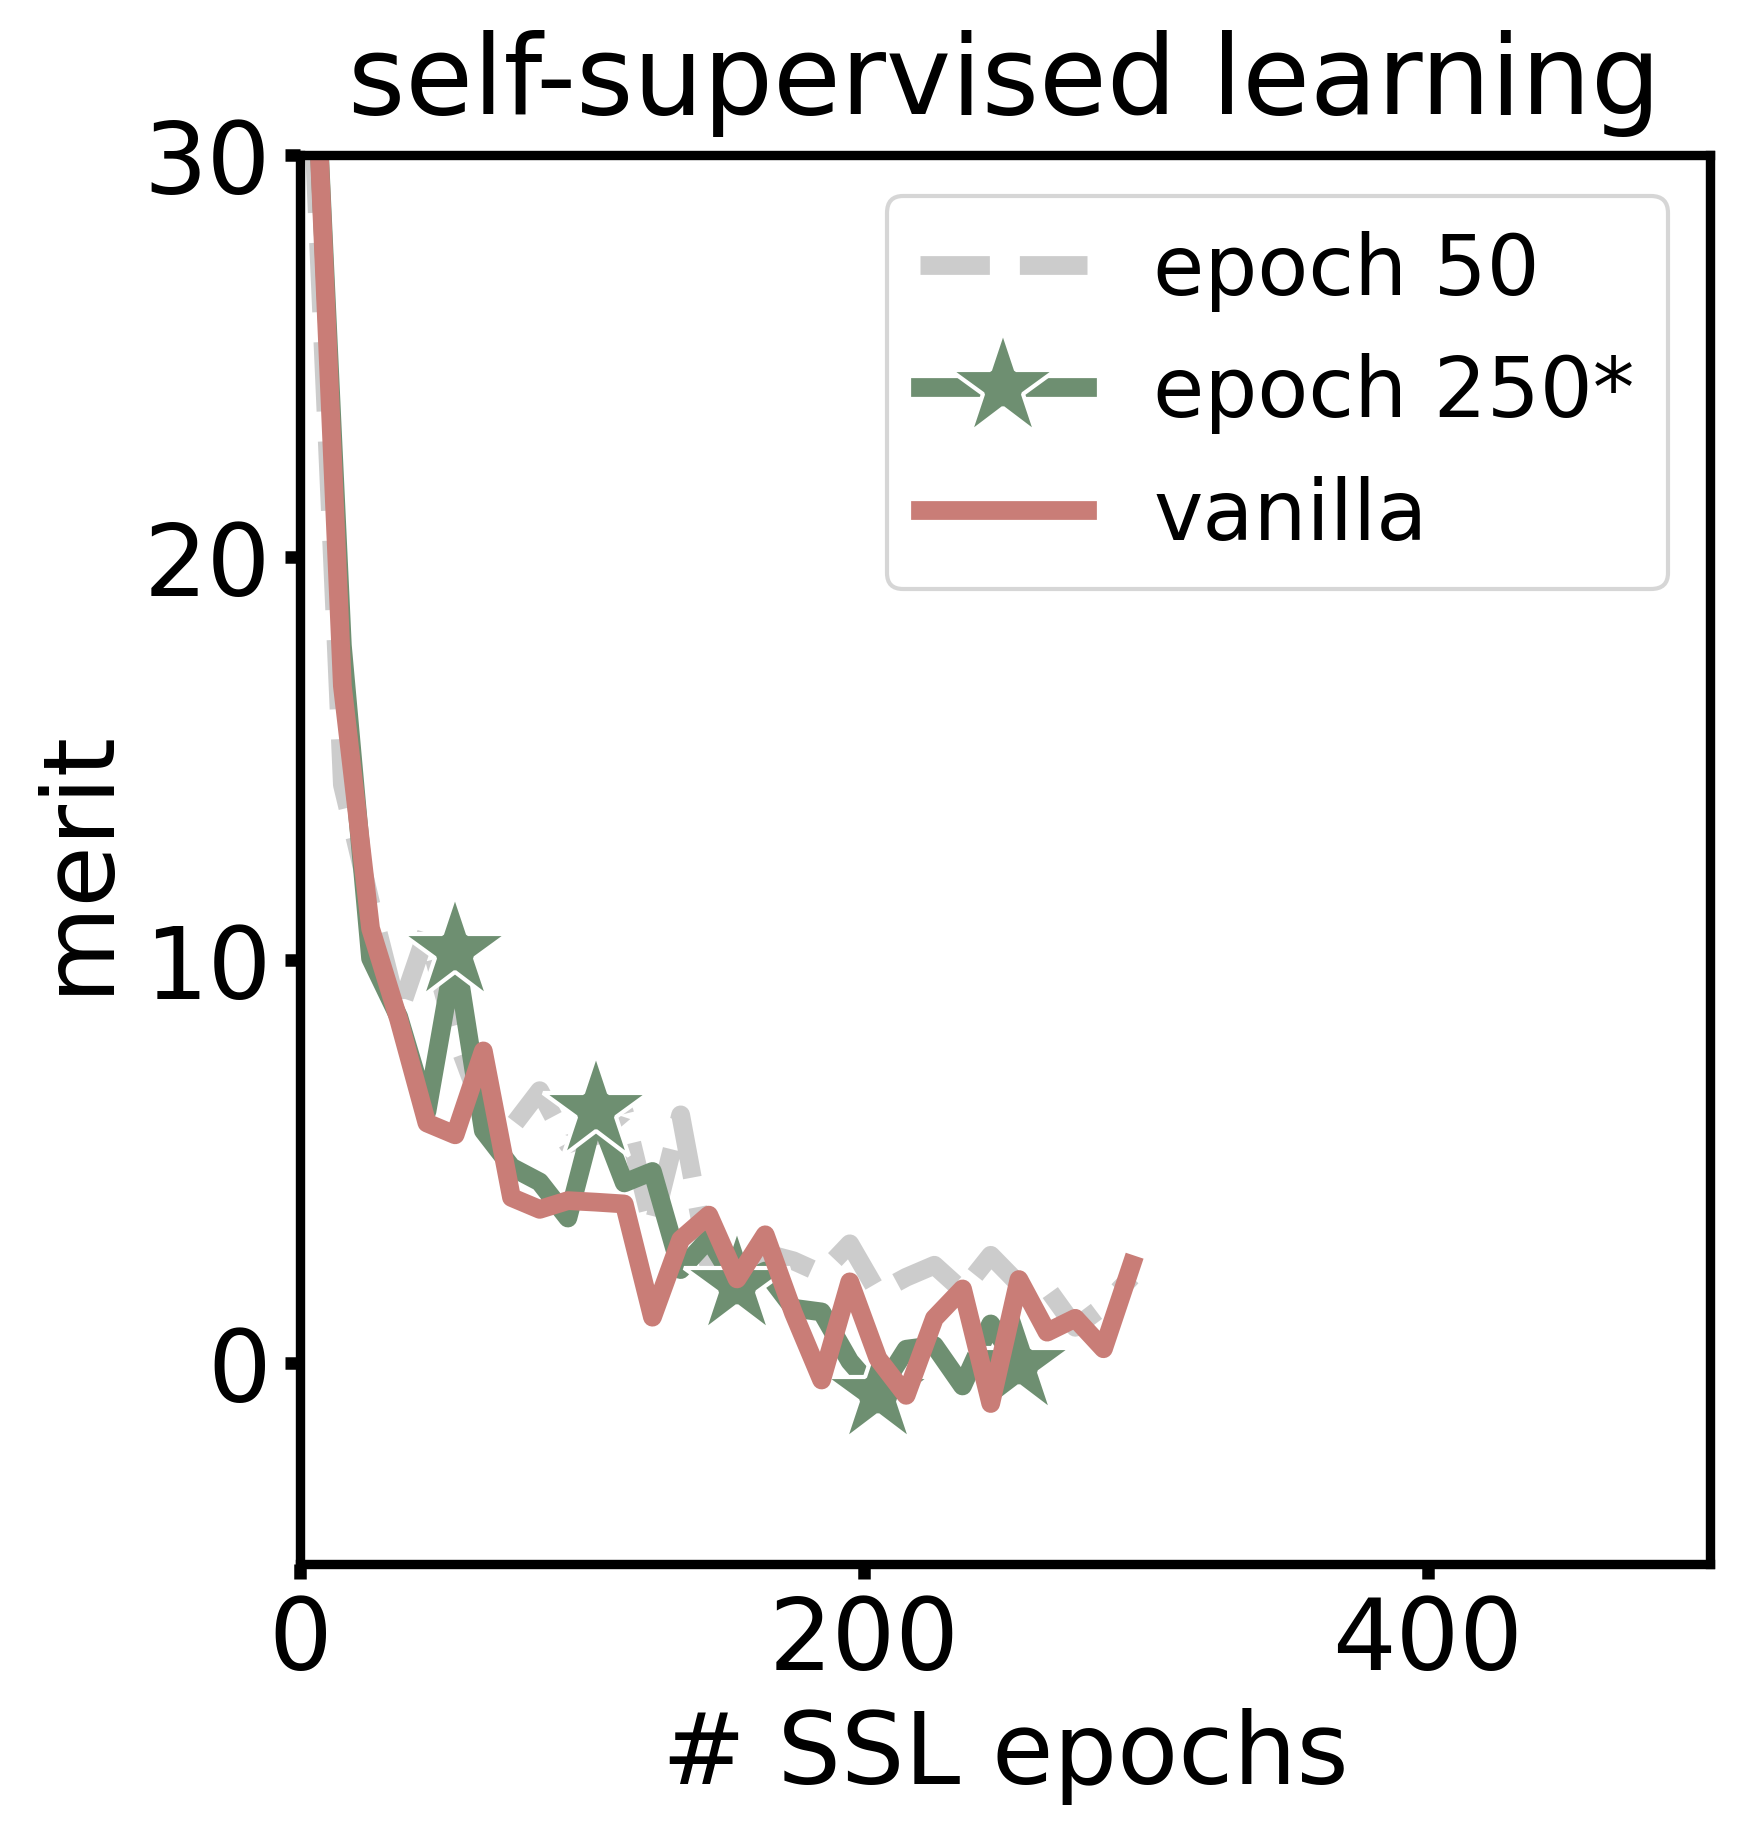

In [172]:
# plot_pretraining_learning(main_result_path, BASE_DIR)
plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')


Saved figures/sl_ssl_merit_correlation.png


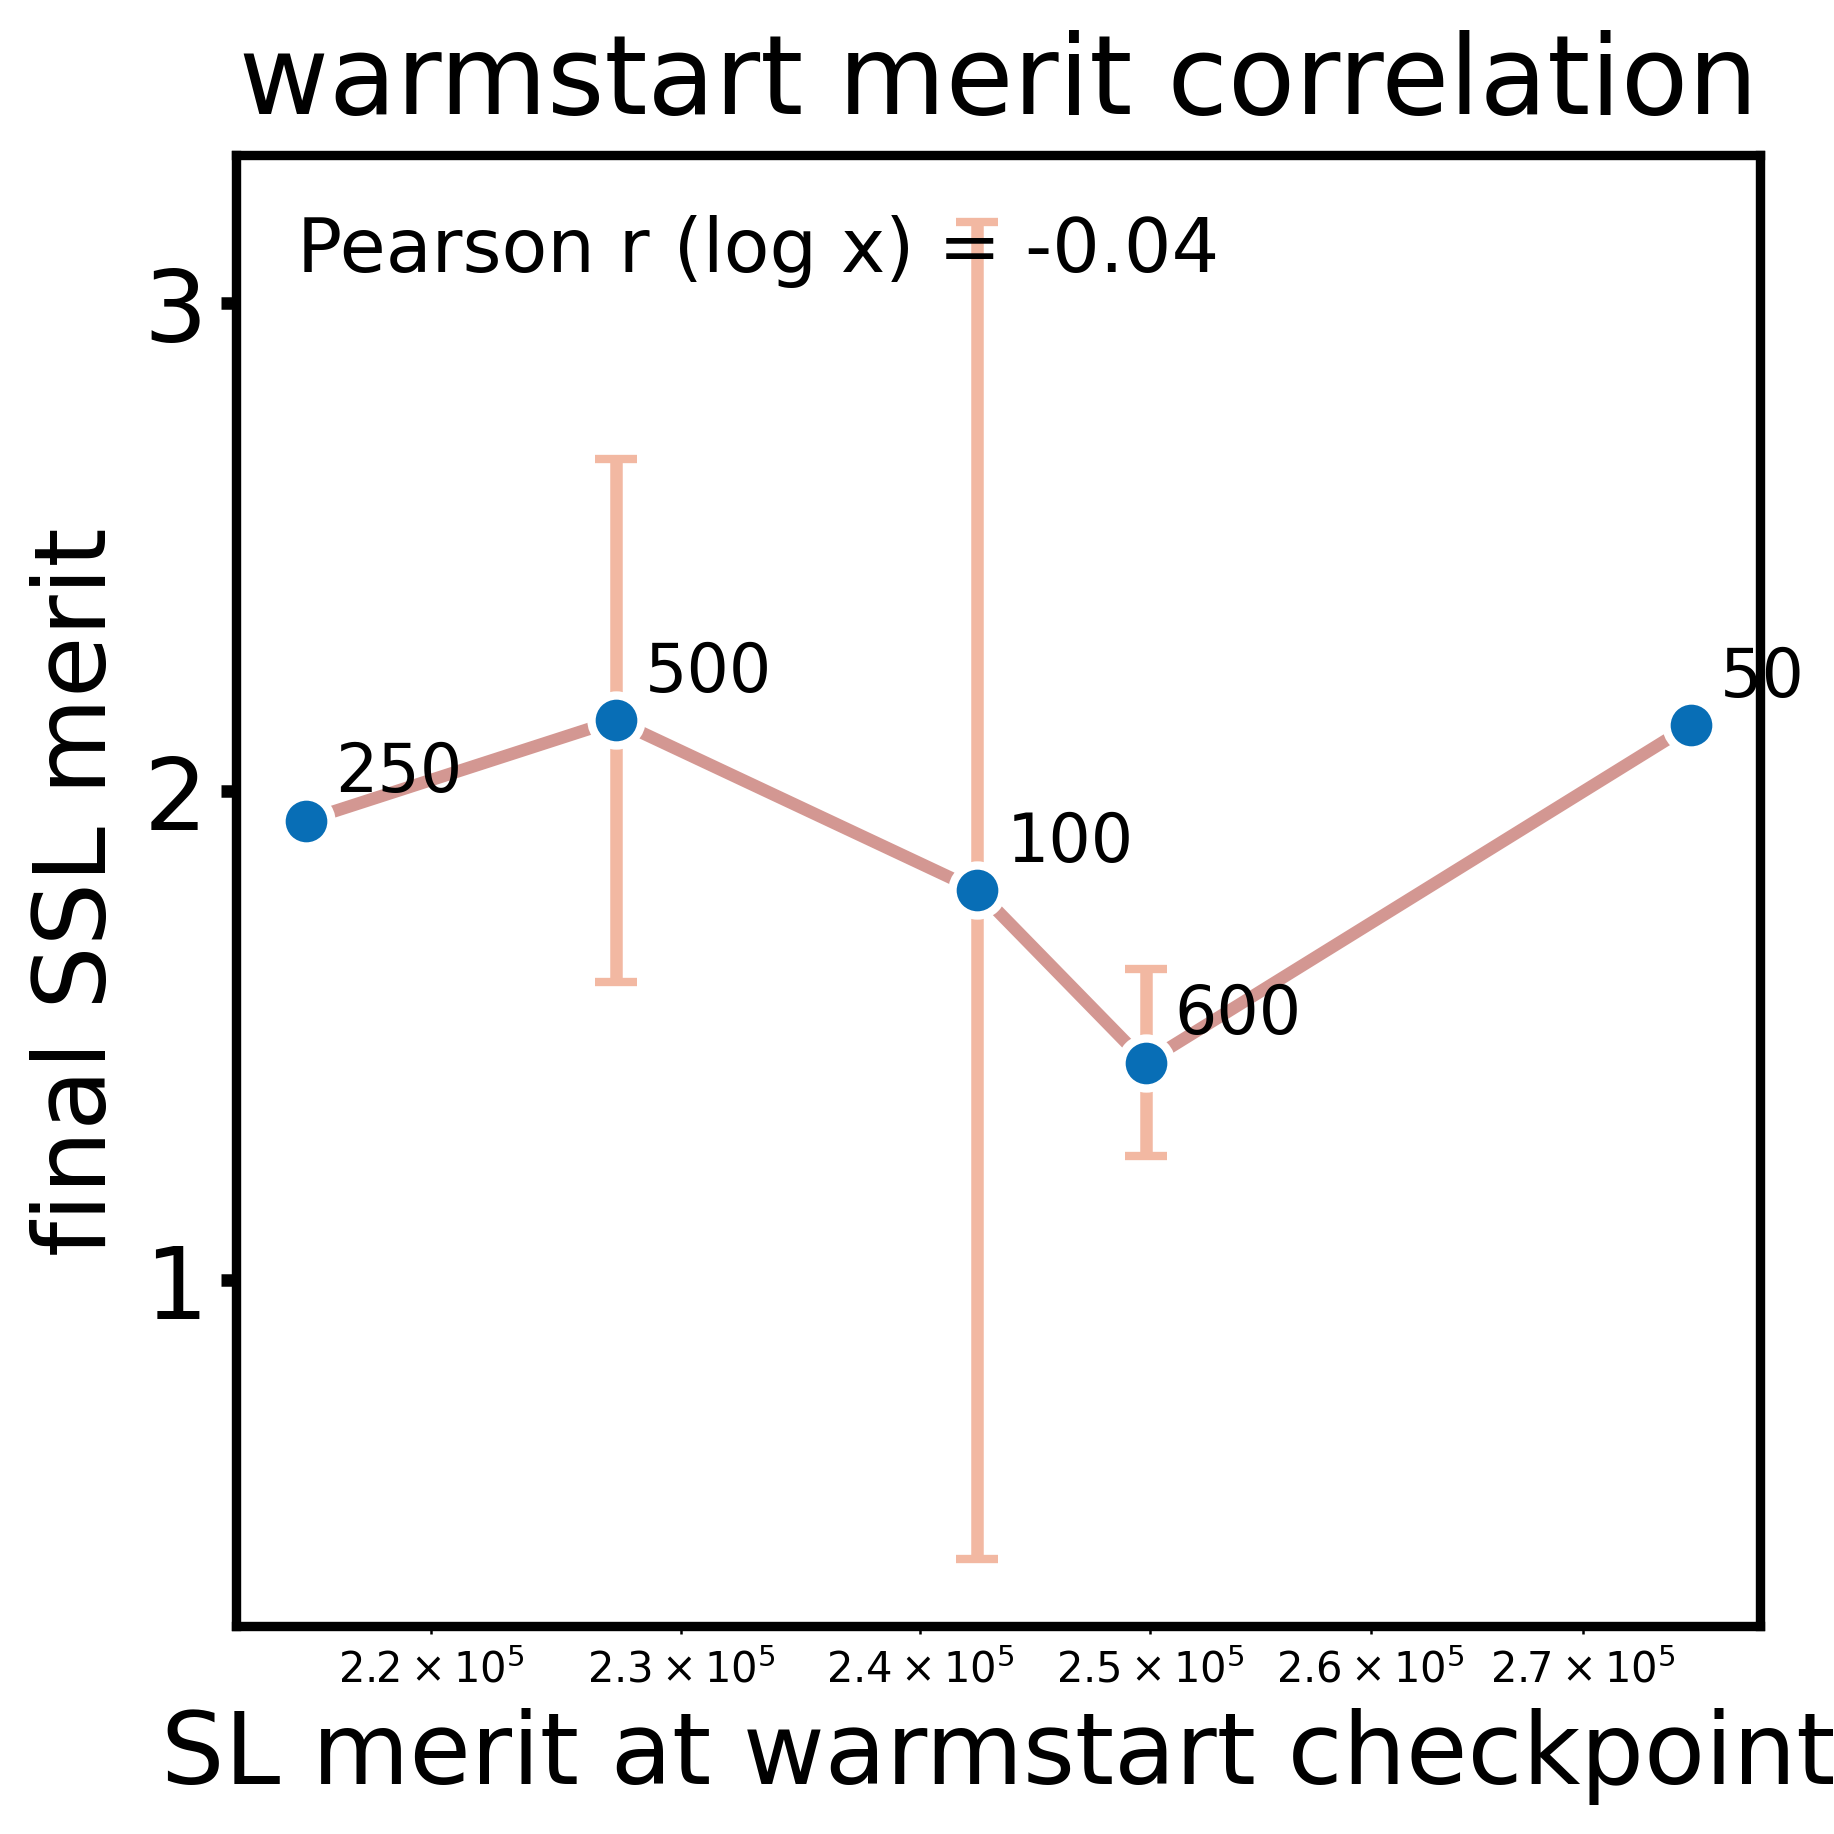

[{'warmstart_epoch': 50,
  'label': 'SL epoch 50',
  'sl_merit': 275241.4959059321,
  'ssl_final_merit_mean': 2.1361973265594654,
  'ssl_final_merit_std': 0.0,
  'num_runs': 1},
 {'warmstart_epoch': 100,
  'label': 'SL epoch 100',
  'sl_merit': 242442.3521281798,
  'ssl_final_merit_mean': 1.7973427731068543,
  'ssl_final_merit_std': 1.369436842980123,
  'num_runs': 4},
 {'warmstart_epoch': 250,
  'label': 'SL epoch 250',
  'sl_merit': 215156.12428588682,
  'ssl_final_merit_mean': 1.9401382192100924,
  'ssl_final_merit_std': 0.0,
  'num_runs': 1},
 {'warmstart_epoch': 500,
  'label': 'SL epoch 500',
  'sl_merit': 227342.40427261015,
  'ssl_final_merit_mean': 2.145291175034468,
  'ssl_final_merit_std': 0.5349611858283613,
  'num_runs': 4},
 {'warmstart_epoch': 600,
  'label': 'SL epoch 600',
  'sl_merit': 249808.02333327194,
  'ssl_final_merit_mean': 1.4445272718315334,
  'ssl_final_merit_std': 0.19073541577611408,
  'num_runs': 3}]

In [173]:
correlation_rows = plot_warmstart_merit_correlation(processed_data, main_result_path, BASE_DIR)
correlation_rows